<a href="https://colab.research.google.com/github/LongLongoooo/Container_Code_Detection/blob/main/Container_Code_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# Đường dẫn tới file zip dataset trên Google Drive của bạn
zip_path = "/content/drive/MyDrive/Container Shipping Number2-Forked on 8-19-2026.coco.zip"

# Thư mục giải nén cục bộ trên Colab (ổ cứng SSD cục bộ chạy cực nhanh)
dataset_dir = "/content/dataset"

Mounted at /content/drive


In [5]:
# Cài đặt thư viện YOLO
!pip install ultralytics

# Kiểm tra xem GPU đã nhận chưa
import torch
print("GPU is available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
GPU is available: True


In [2]:
import os
import zipfile
import json
import shutil
import glob

# 1. Giải nén dataset vào thư mục cục bộ của Colab
print("Đang giải nén dataset...")
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)
os.makedirs(dataset_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)
print("Giải nén hoàn tất!")

# 2. Chuyển đổi định dạng từ COCO JSON sang YOLO TXT
splits = ['train', 'valid', 'test']

# Ánh xạ ID loại nhãn từ COCO sang YOLO:
# COCO id 1: 'container-number' -> YOLO class 0
# COCO id 2: 'iso-type' -> YOLO class 1
category_mapping = {
    1: 0,
    2: 1
}

for split in splits:
    split_dir = os.path.join(dataset_dir, split)
    ann_file = os.path.join(split_dir, '_annotations.coco.json')

    if not os.path.exists(ann_file):
        print(f"Bỏ qua split '{split}' vì không tìm thấy file annotation JSON.")
        continue

    print(f"Đang chuyển đổi split '{split}'...")

    # Tạo thư mục images/ và labels/ chuẩn theo yêu cầu của YOLO
    images_dir = os.path.join(split_dir, 'images')
    labels_dir = os.path.join(split_dir, 'labels')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    # Đọc file COCO JSON
    with open(ann_file, 'r', encoding='utf-8') as f:
        coco_data = json.load(f)

    # Tạo map từ image_id sang thông tin ảnh
    image_map = {img['id']: img for img in coco_data['images']}

    # Khởi tạo danh sách nhãn trống cho từng ảnh
    image_labels = {img_id: [] for img_id in image_map.keys()}

    # Duyệt qua các annotation để chuyển sang định dạng YOLO
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        cat_id = ann['category_id']

        # Bỏ qua nếu nhãn không nằm trong danh sách ánh xạ
        if cat_id not in category_mapping:
            continue

        class_id = category_mapping[cat_id]
        bbox = ann['bbox'] # [x_min, y_min, width, height]

        img_info = image_map[img_id]
        img_w = img_info['width']
        img_h = img_info['height']

        # Chuyển đổi tọa độ
        x_min, y_min, w, h = bbox
        x_center = x_min + w / 2.0
        y_center = y_min + h / 2.0

        # Chuẩn hóa về [0, 1]
        x_center_norm = x_center / img_w
        y_center_norm = y_center / img_h
        w_norm = w / img_w
        h_norm = h / img_h

        image_labels[img_id].append(f"{class_id} {x_center_norm:.6f} {y_center_norm:.6f} {w_norm:.6f} {h_norm:.6f}")

    # Di chuyển ảnh vào images/ và tạo labels txt
    for img_id, img_info in image_map.items():
        file_name = img_info['file_name']
        src_img_path = os.path.join(split_dir, file_name)
        dest_img_path = os.path.join(images_dir, file_name)

        if os.path.exists(src_img_path):
            shutil.move(src_img_path, dest_img_path)

        base_name = os.path.splitext(file_name)[0]
        label_file_path = os.path.join(labels_dir, f"{base_name}.txt")

        with open(label_file_path, 'w', encoding='utf-8') as lf:
            lf.write('\n'.join(image_labels[img_id]) + ('\n' if image_labels[img_id] else ''))

    # Xóa file JSON cũ
    os.remove(ann_file)
    print(f"Hoàn tất chuyển đổi split '{split}'!")

# 3. Tạo file data.yaml cấu hình cho YOLO
yaml_content = f"""path: {dataset_dir}
train: train/images
val: valid/images
test: test/images

names:
  0: container_code
  1: iso_type
"""
yaml_path = os.path.join(dataset_dir, 'data.yaml')
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write(yaml_content)
print(f"Đã ghi cấu hình file data.yaml tại: {yaml_path}")

# 4. In thông tin thống kê
print("\n=== THỐNG KÊ DATASET ĐÃ CHUYỂN ĐỔI ===")
for split in splits:
    images_count = len(glob.glob(os.path.join(dataset_dir, split, 'images', '*')))
    labels_count = len(glob.glob(os.path.join(dataset_dir, split, 'labels', '*.txt')))
    print(f"Split [{split}]: {images_count} ảnh | {labels_count} file nhãn .txt")

Đang giải nén dataset...
Giải nén hoàn tất!
Đang chuyển đổi split 'train'...
Hoàn tất chuyển đổi split 'train'!
Đang chuyển đổi split 'valid'...
Hoàn tất chuyển đổi split 'valid'!
Đang chuyển đổi split 'test'...
Hoàn tất chuyển đổi split 'test'!
Đã ghi cấu hình file data.yaml tại: /content/dataset/data.yaml

=== THỐNG KÊ DATASET ĐÃ CHUYỂN ĐỔI ===
Split [train]: 593 ảnh | 593 file nhãn .txt
Split [valid]: 115 ảnh | 115 file nhãn .txt
Split [test]: 37 ảnh | 37 file nhãn .txt


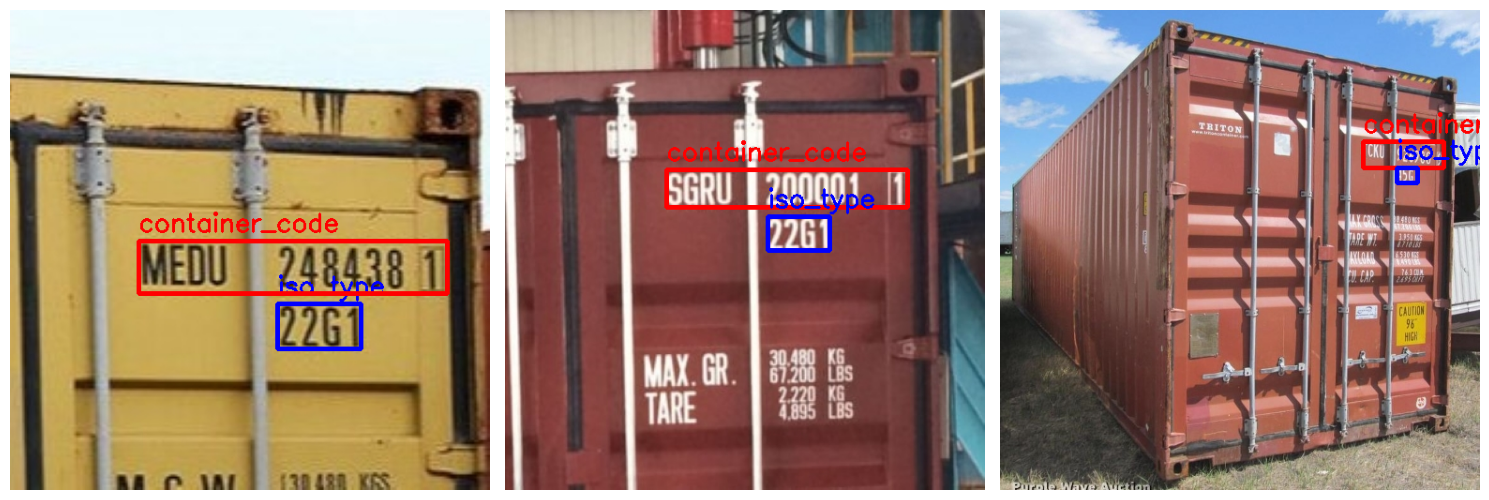

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
import glob

# Định nghĩa class name
class_names = ['container_code', 'iso_type']

# Sử dụng biến dataset_dir đã định nghĩa ở trên
img_dir = os.path.join(dataset_dir, 'train/images')
label_dir = os.path.join(dataset_dir, 'train/labels')

# Lấy thử 3 ảnh đầu tiên
img_files = glob.glob(os.path.join(img_dir, '*'))[:3]

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(img_files):
    # Đọc ảnh
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Tìm file label tương ứng (hỗ trợ mọi định dạng ảnh)
    img_name = os.path.basename(img_path)
    txt_name = os.path.splitext(img_name)[0] + '.txt'
    txt_path = os.path.join(label_dir, txt_name)

    # Đọc tọa độ và vẽ box
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])

                    # Chuyển đổi tọa độ chuẩn hóa về pixel
                    x_min = int((x_center - width/2) * w)
                    y_min = int((y_center - height/2) * h)
                    x_max = int((x_center + width/2) * w)
                    y_max = int((y_center + height/2) * h)

                    # Vẽ hộp chữ nhật (đỏ cho container_code, xanh cho iso_type)
                    color = (255, 0, 0) if class_id == 0 else (0, 0, 255)
                    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 3)

                    # Thêm nhãn
                    label = class_names[class_id] if class_id < len(class_names) else f"Unknown ID: {class_id}"
                    cv2.putText(img, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
from ultralytics import YOLO
model = YOLO('yolo11n.pt')
print(model.ckpt["train_args"])


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{'task': 'detect', 'mode': 'train', 'model': 'yolo11n.yaml', 'data': '/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml', 'epochs': 600, 'time': None, 'patience': 100, 'batch': 128, 'imgsz': 640, 'save': True, 'save_period': -1, 'cache': 'disk', 'device': 0, 'workers': 8, 'project': 'exp10-new', 'name': 'yolov8n-c3k2-6', 'exist_ok': False, 'pretrained': True, 'optimizer': 'auto', 'verbose': True, 'seed': 0, 'deterministic': True, 'single_cls': False, 'rect': False, 'cos_lr': False, 'close_mosaic': 10, 'resume': False, 'amp': True, 'fraction': 1.0, 'profile': False, 'freeze': None, 'multi_scale': False, 'overlap_mask': True, 'mask_ratio': 4, 'dropout': 0.0, 'val': True, 'spli

In [8]:
from ultralytics import YOLO
import torch

# Khởi tạo mô hình
model = YOLO('yolo11n.pt')

# Tự động chọn GPU nếu có, ngược lại dùng CPU
device_choice = 0 if torch.cuda.is_available() else 'cpu'
print(f"Sử dụng thiết bị: {device_choice}")

# Tiến hành huấn luyện với cấu hình đã chuẩn hóa
results = model.train(
    data=os.path.join(dataset_dir, 'data.yaml'),
    epochs=50,                  # Chạy 50 epochs (bạn có thể tăng/giảm tùy ý)
    imgsz=640,
    batch=16,                   # Batch size 16 phù hợp với GPU T4 miễn phí của Colab
    device=device_choice,
    project='/content/drive/MyDrive/Container_Code_Training', # Lưu kết quả train trực tiếp lên Google Drive để tránh bị mất
    name='container_yolo_final',
    patience=20
)

Sử dụng thiết bị: 0
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=container_yolo